In [2]:
using Revise
using SSMCMain, SSMCMain.ModifiedMiCRM, SSMCMain.ModifiedMiCRM.MinimalModelV2, SSMCMain.ModifiedMiCRM.TwoMMs

In [51]:
using JLD2
using DataFrames, DataFramesMeta
using ColorSchemes

In [4]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Coexistence region with K with p

In [38]:
close(f)
GC.gc()

In [49]:
f = jldopen("../../cluster_env/runs/twomms1/wrtp/df.jld2")
df = f["df"]
fmetadata = f["metadata"];
ps = sort(unique(df.p))
Ks = sort(unique(df.K))
numKs = length(Ks)
@assert Ks == fmetadata.Ks

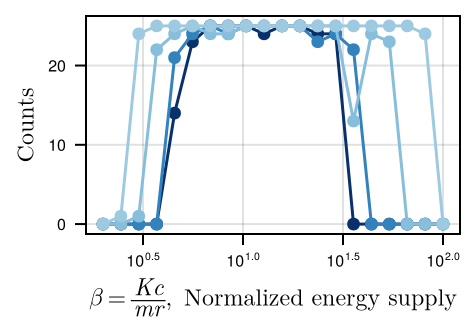

In [60]:
surv_threshold = 1e-9

cc = cgrad(ColorSchemes.Blues[4:end])
pmin, pmax = extrema(ps)
pdelta = pmax - pmin

fig = Figure(;
    size=(double_col_width * 0.35, (double_col_width / golden_ratio) * 0.4),
    figure_padding=(8., 8., 8., 8.),
)
ax = Axis(fig[1,1];
    xscale=log10,
    xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
    ylabel=L"\text{Counts}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

pgroups = groupby(df, :p);

for sdf1 in pgroups
    p = sdf1.p[1]

    num_ext = zeros(numKs)
    num_coex = zeros(numKs)
    num_S1 = zeros(numKs)
    num_S2 = zeros(numKs)
    num_bad = zeros(numKs)
    for iK in 1:length(Ks)
        xx = sdf1[sdf1.K .== Ks[iK],:]
        for r in eachrow(xx)
            if (r.fT == fmetadata.T) && (r.retcode == ReturnCode.Success)
                m1 = mean(@view r.fs[1,:])
                m2 = mean(@view r.fs[2,:])
                if (m1 < surv_threshold) && (m2 < surv_threshold)
                    num_ext[iK] += 1
                elseif (m1 < surv_threshold)
                    num_S2[iK] += 1
                elseif (m2 < surv_threshold)
                    num_S1[iK] += 1
                else
                    num_coex[iK] += 1
                end
            else
                num_bad[iK] += 1
            end
        end
    end
    @assert all((num_ext .+ num_coex .+ num_S1 .+ num_S2 .+ num_bad) .== fmetadata.numrepeats)

    ccrat = (p - pmin) / pdelta
    scatterlines!(ax, Ks, num_coex;
        color=get(cc, ccrat),
    )
    # plot_binom_sample!(ax, Ks, num_coex, fmetadata.numrepeats;
        # color=get(cc, ccrat),
    # )

end

fig

# Outcome with K first example

In [63]:
# f = jldopen("../../cluster_env/runs/twomms1/wrtk_1/d1_k0.0.jld2")
f = jldopen("../../cluster_env/runs/twomms1/wrtp/d1_p0.1.jld2")
fmetadata = f["metadata"]

Ks = f["Ks"]
numKs = length(Ks)
results = f["results"];

In [66]:
surv_threshold = 1e-9
num_ext = zeros(numKs)
num_coex = zeros(numKs)
num_S1 = zeros(numKs)
num_S2 = zeros(numKs)
num_bad = zeros(numKs)
for iK in 1:length(Ks)
    for (rc, fT, fs) in zip(results[iK].retcodes, results[iK].fTs, results[iK].fss)
        if (fT == fmetadata.T) && (rc == ReturnCode.Success)
            m1 = mean(@view fs[1,:])
            m2 = mean(@view fs[2,:])
            if (m1 < surv_threshold) && (m2 < surv_threshold)
                num_ext[iK] += 1
            elseif (m1 < surv_threshold)
                num_S2[iK] += 1
            elseif (m2 < surv_threshold)
                num_S1[iK] += 1
            else
                num_coex[iK] += 1
            end
        else
            num_bad[iK] += 1
        end
    end
end
@assert all((num_ext .+ num_coex .+ num_S1 .+ num_S2 .+ num_bad) .== fmetadata.numrepeats)

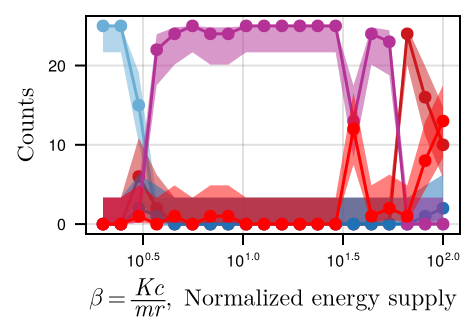

In [68]:
fig = Figure(;
    size=(double_col_width * 0.35, (double_col_width / golden_ratio) * 0.4),
    figure_padding=(8., 8., 8., 8.),
)
ax = Axis(fig[1,1];
    xscale=log10,
    xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
    ylabel=L"\text{Counts}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

plot_binom_sample!(ax, Ks, num_ext, fmetadata.numrepeats;
    color=PaperColors.extinct1(),
    label="Extinction",
)
plot_binom_sample!(ax, Ks, num_S1, fmetadata.numrepeats;
    color=PaperColors.twomms_1(),
    label="Only 1",
)
plot_binom_sample!(ax, Ks, num_S2, fmetadata.numrepeats;
    color=PaperColors.twomms_2(),
    label="Only 2",
)
plot_binom_sample!(ax, Ks, num_coex, fmetadata.numrepeats;
    color=PaperColors.twomms_coexistence(),
    label="Coexistence",
)
plot_binom_sample!(ax, Ks, num_bad, fmetadata.numrepeats;
    color=:red,
    label="Bad",
)

# vlines!(ax, [Ks[4], Ks[11]];
    # color=:black,
    # linestyle=:dash,
# )

ax.yticks = 0:10:50

# Makie.save("../../figures2/fig3/props_1.pdf", fig)

fig

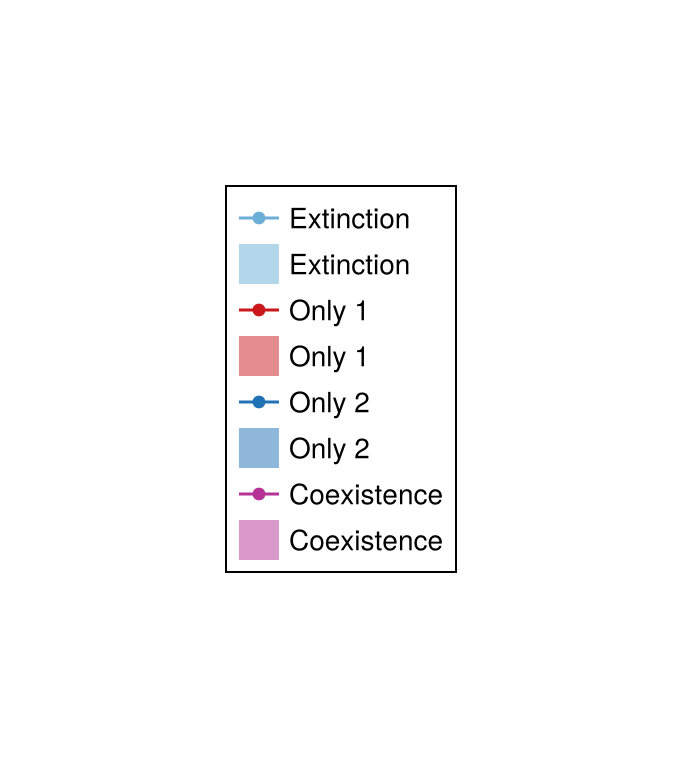

In [51]:
fig = Figure(;
    # size=(double_col_width * 0.45, (double_col_width / golden_ratio) * 0.52),
    figure_padding=(8., 8., 8., 8.),
    size=(double_col_width * 0.5, (double_col_width / golden_ratio) * 0.9),
)
Legend(fig[1,1], ax;
    # labelsize=6fontsize_pt,
)
Makie.save("../../figures2/fig3/props_legend_sample.pdf", fig)
fig